# Barebones Injection Output Plots

1. Plot original simulation strain (`hp`, `hc`).
2. Plot final injected signal overlay: noisy on top of no-noise (H1 and L1).


In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
BASE = Path('/home/selmavangstein/mastersproject')
DATADIR = BASE / 'datadir' / 'bilby_output'

# Original simulation (source polarizations)
HP_CSV = DATADIR / 'hp.csv'
HC_CSV = DATADIR / 'hc.csv'

# Final injected data products
NOISY_PREFIX = 'total'        # e.g. output from noise=True run
NONOISE_PREFIX = 'ref_nonoise'  # e.g. output from noise=False run

NOISY_H1_H5 = DATADIR / f'{NOISY_PREFIX}_H1_injection_data.h5'
NOISY_L1_H5 = DATADIR / f'{NOISY_PREFIX}_L1_injection_data.h5'
NOISY_META = DATADIR / f'{NOISY_PREFIX}_injection_metadata.csv'

NONOISE_H1_H5 = DATADIR / f'{NONOISE_PREFIX}_H1_injection_data.h5'
NONOISE_L1_H5 = DATADIR / f'{NONOISE_PREFIX}_L1_injection_data.h5'
NONOISE_META = DATADIR / f'{NONOISE_PREFIX}_injection_metadata.csv'

print('DATADIR:', DATADIR)
print('HP_CSV exists:', HP_CSV.exists())
print('HC_CSV exists:', HC_CSV.exists())
print('NOISY_H1_H5 exists:', NOISY_H1_H5.exists())
print('NONOISE_H1_H5 exists:', NONOISE_H1_H5.exists())


DATADIR: /home/selmavangstein/mastersproject/datadir/bilby_output
HP_CSV exists: True
HC_CSV exists: True
NOISY_H1_H5 exists: True
NONOISE_H1_H5 exists: True


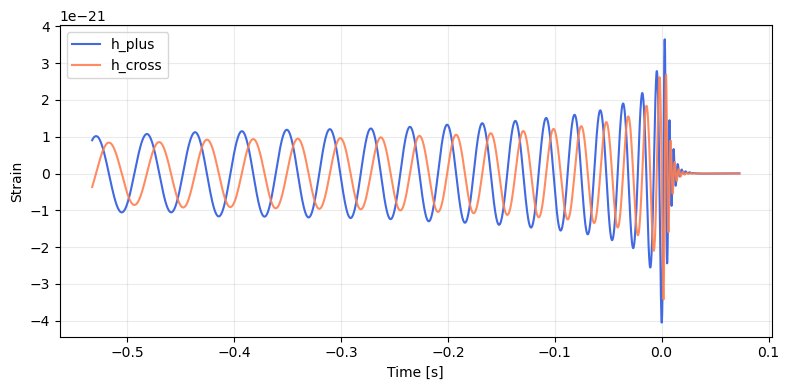

In [3]:
# 1) Original simulation strain (source-frame h+ and hx)
hp_df = pd.read_csv(HP_CSV)
hc_df = pd.read_csv(HC_CSV)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hp_df['times'], hp_df['strain'], lw=1.5, color='royalblue', label='h_plus')
ax.plot(hc_df['times'], hc_df['strain'], lw=1.5, color='coral', label='h_cross', alpha=0.9)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Strain')
#ax.set_title('Original Simultion Strain')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
def load_h5_timeseries(path):
    with h5py.File(path, 'r') as f:
        t = np.asarray(f['times'][:])
        h = np.asarray(f['strain'][:])
    return t, h

noisy_meta = pd.read_csv(NOISY_META).iloc[0]
nonoise_meta = pd.read_csv(NONOISE_META).iloc[0]

# Read H1 and L1 noisy + no-noise
h1_t_noisy, h1_h_noisy = load_h5_timeseries(NOISY_H1_H5)
l1_t_noisy, l1_h_noisy = load_h5_timeseries(NOISY_L1_H5)

h1_t_clean, h1_h_clean = load_h5_timeseries(NONOISE_H1_H5)
l1_t_clean, l1_h_clean = load_h5_timeseries(NONOISE_L1_H5)

# Shift to detector peak-relative time for easier visual comparison
h1_t_noisy_rel = h1_t_noisy - float(noisy_meta['h1_peak_time'])
l1_t_noisy_rel = l1_t_noisy - float(noisy_meta['l1_peak_time'])

h1_t_clean_rel = h1_t_clean - float(nonoise_meta['h1_peak_time'])
l1_t_clean_rel = l1_t_clean - float(nonoise_meta['l1_peak_time'])


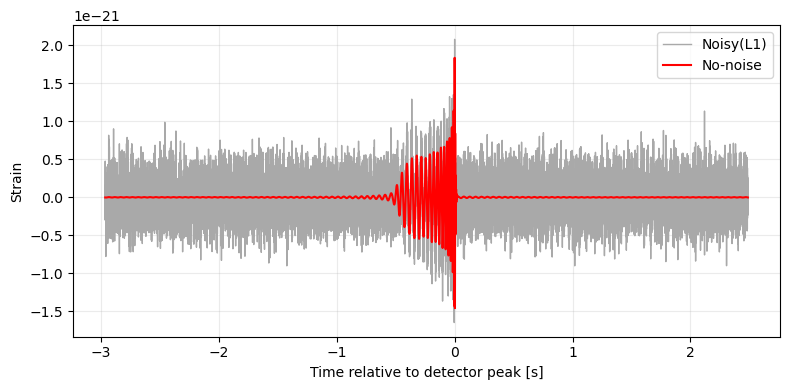

In [5]:
# Injected signal comparison: Noisy vs No-noise in L1
plt.figure(figsize=(8, 4))
plt.plot(l1_t_noisy_rel, l1_h_noisy, lw=1.0, color='darkgrey', label='Noisy(L1)')
plt.plot(l1_t_clean_rel, l1_h_clean, lw=1.5, color='red', label='No-noise')
plt.xlabel(r'Time relative to detector peak [s]')
plt.ylabel('Strain')
#plt.title('Final Injected Signal: Noisy vs No-noise (L1)')
#plt.xlim(-0.6,0.15)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

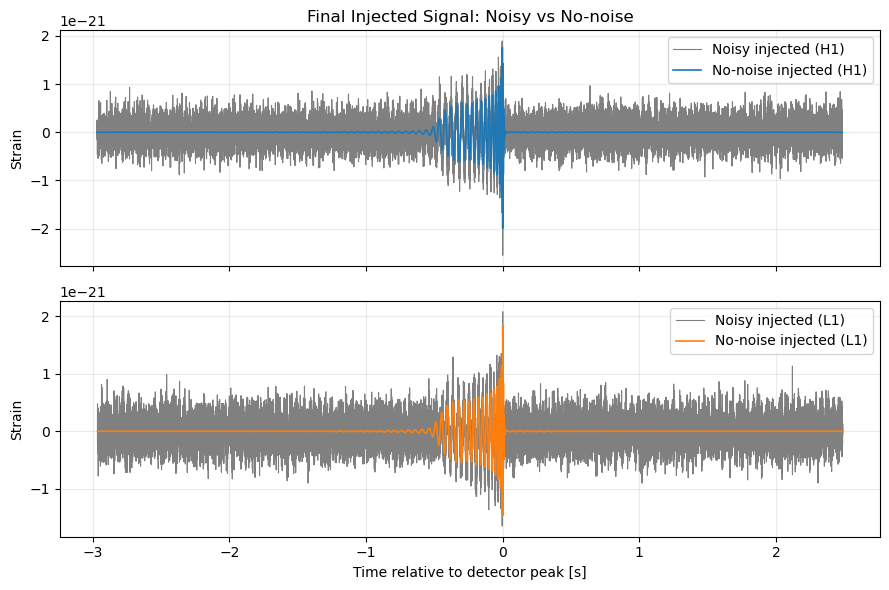

In [6]:
# 2) Final injected signal: noisy overlaid on no-noise (H1 and L1)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# H1
a = axes[0]
a.plot(h1_t_noisy_rel, h1_h_noisy, lw=0.8, color='grey', label='Noisy injected (H1)')
a.plot(h1_t_clean_rel, h1_h_clean, lw=1.2, alpha=1.0, label='No-noise injected (H1)')
a.set_ylabel('Strain')
a.set_title('Final Injected Signal: Noisy vs No-noise')
a.grid(alpha=0.25)
a.legend(loc='upper right')

# L1
a = axes[1]
a.plot(l1_t_noisy_rel, l1_h_noisy, lw=0.8, color='grey', label='Noisy injected (L1)')
a.plot(l1_t_clean_rel, l1_h_clean, lw=1.2, color='tab:orange', label='No-noise injected (L1)')
a.set_xlabel(r'Time relative to detector peak [s]')
a.set_ylabel('Strain')
a.grid(alpha=0.25)
a.legend(loc='upper right')

plt.tight_layout()
plt.show()


Saved summary plot to: /home/selmavangstein/mastersproject/gw_boson_star_testing_gr/good_plots/bilby/summary.png


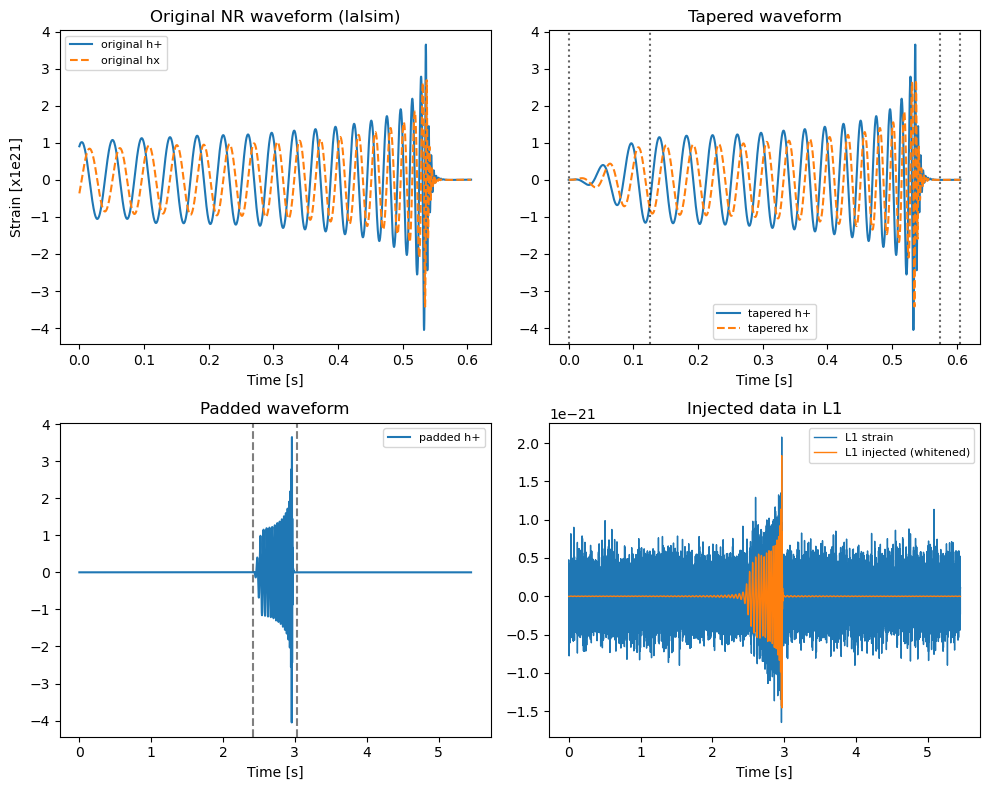

In [7]:
from scipy.interpolate import UnivariateSpline
from scipy.optimize import root_scalar
from scipy.signal import butter, sosfiltfilt

BEGINNING_TAPER_SAFETY = 2
END_TAPER_SAFETY = 8


def window(times, t0, t1, direction='on'):
    taper = np.ones_like(times)
    mask = (times >= t0) & (times <= t1)
    x = (times[mask] - t0) / (t1 - t0)
    taper[mask] = 0.5 * (1 - np.cos(np.pi * x))

    if direction == 'off':
        taper[mask] = 1 - taper[mask]
        taper[times < t0] = 1.0
        taper[times > t1] = 0.0
    else:
        taper[times < t0] = 0.0
        taper[times > t1] = 1.0

    return taper


def find_peaks(hp):
    d_hp = np.diff(hp)
    sign_change = (d_hp[:-1] > 0) & (d_hp[1:] < 0)
    return np.where(sign_change)[0] + 1


def load_h5(path):
    with h5py.File(path, 'r') as f:
        t = np.asarray(f['times'][:])
        h = np.asarray(f['strain'][:])
    return t, h


# Load original source-frame waveform
hp_df = pd.read_csv(HP_CSV)
hc_df = pd.read_csv(HC_CSV)

original_hp = hp_df['strain'].to_numpy()
original_hc = hc_df['strain'].to_numpy()

# Convert to the same convention as the old full_working_pipeline summary plot
times = hp_df['times'].to_numpy()
times = times - times.min()
dt = float(np.median(np.diff(times)))

# Start taper from instantaneous-frequency criterion
phase = np.arctan2(original_hc, original_hp)
unwrapped_phase = np.unwrap(phase)
phase_spline = UnivariateSpline(times, unwrapped_phase, k=3, s=0)
omega_interp = phase_spline.derivative()
frequency = omega_interp(times) / (2.0 * np.pi)

try:
    sol = root_scalar(
        lambda t1: (1 + BEGINNING_TAPER_SAFETY) * (1.0 / t1) - omega_interp(t1) / (2.0 * np.pi),
        x0=0.1,
        bracket=[0.01, min(0.3, times[-1] * 0.95)],
    )
    t1 = float(sol.root)
except Exception:
    meta_for_fallback = pd.read_csv(NONOISE_META).iloc[0]
    fmin = float(meta_for_fallback.get('f_min', np.nan))
    idx = np.where(frequency >= fmin)[0]
    t1 = float(times[idx[0]]) if len(idx) else float(times[int(0.1 * len(times))])

t0 = 0.0
taper = window(times, t0, t1, direction='on')
tapered_hp = original_hp * taper
tapered_hc = original_hc * taper

# End taper using nth-last peak
peaks = find_peaks(original_hp)
if len(peaks) >= END_TAPER_SAFETY:
    idx_taper = peaks[-END_TAPER_SAFETY]
elif len(peaks):
    idx_taper = peaks[0]
else:
    idx_taper = len(times) - 1

t_start = float(times[idx_taper])
t_end = float(times[-1])
if t_start < t_end:
    end_taper = window(times, t_start, t_end, direction='off')
    taper = taper * end_taper
    tapered_hp = tapered_hp * end_taper
    tapered_hc = tapered_hc * end_taper

# Zero-padding
meta = pd.read_csv(NONOISE_META).iloc[0]
pad_time = float(meta.get('pad_time', np.nan))
if np.isfinite(pad_time) and pad_time > 0:
    pad_length = int(round(pad_time / dt))
else:
    pad_length = int(len(times) * 4)

signal_length = len(times)
times_before = times[0] - np.arange(pad_length, 0, -1) * dt
times_after = times[-1] + np.arange(1, pad_length + 1) * dt
times_padded = np.concatenate([times_before, times, times_after])
times_padded = times_padded - times_padded[0]

padded_hp = np.pad(tapered_hp, pad_length, mode='constant', constant_values=0)
padded_hc = np.pad(tapered_hc, pad_length, mode='constant', constant_values=0)

# Preprocessing: same branch as full_working_pipeline (bandpass when available)
fs = float(meta.get('sampling_frequency', 1.0 / dt))
lowcut = float(meta.get('f_min', np.nan))
highcut = float(meta.get('f_max', np.nan))

if np.isfinite(lowcut) and np.isfinite(highcut) and (0 < lowcut < highcut < 0.5 * fs):
    sos = butter(4, [lowcut, highcut], btype='band', fs=fs, output='sos')
    preprocessed_hp = sosfiltfilt(sos, padded_hp)
    preprocessed_hc = sosfiltfilt(sos, padded_hc)
else:
    preprocessed_hp = padded_hp
    preprocessed_hc = padded_hc

# L1 injected data (noisy and no-noise overlay)
l1_t_noisy, l1_h_noisy = load_h5(NOISY_L1_H5)
l1_t_clean, l1_h_clean = load_h5(NONOISE_L1_H5)
l1_t_noisy_plot = l1_t_noisy - l1_t_noisy[0]
l1_t_clean_plot = l1_t_clean - l1_t_clean[0]

# Frequency-domain strain from preprocessed plus/cross
fr_array = np.fft.rfftfreq(len(preprocessed_hp), d=dt)
fr_plus = np.fft.rfft(preprocessed_hp) * dt
fr_cross = np.fft.rfft(preprocessed_hc) * dt
freq_mask = fr_array > 0

# Recreate summary panel without bandpass/frequency-domain frames
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes.flatten()

ax[0].plot(times, 1e21 * original_hp, label='original h+')
ax[0].plot(times, 1e21 * original_hc, ls='--', label='original hx')
ax[0].set_title('Original NR waveform (lalsim)')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Strain [x1e21]')
ax[0].legend(fontsize=8)

ax[1].plot(times, 1e21 * tapered_hp, label='tapered h+')
ax[1].plot(times, 1e21 * tapered_hc, ls='--', label='tapered hx')
ax[1].axvline(t0, color='k', ls=':', alpha=0.6)
ax[1].axvline(t1, color='k', ls=':', alpha=0.6)
ax[1].axvline(t_start, color='k', ls=':', alpha=0.6)
ax[1].axvline(t_end, color='k', ls=':', alpha=0.6)
ax[1].set_title('Tapered waveform')
ax[1].set_xlabel('Time [s]')
ax[1].legend(fontsize=8)

ax[2].plot(times_padded, 1e21 * padded_hp, label='padded h+')
ax[2].axvline(times_padded[pad_length], color='k', ls='--', alpha=0.5)
ax[2].axvline(times_padded[pad_length + signal_length - 1], color='k', ls='--', alpha=0.5)
ax[2].set_title('Padded waveform')
ax[2].set_xlabel('Time [s]')
ax[2].legend(fontsize=8)

ax[3].plot(l1_t_noisy_plot, l1_h_noisy, label='L1 strain', lw=1.0)
ax[3].plot(l1_t_clean_plot, l1_h_clean, label='L1 injected (whitened)', lw=1.0)
ax[3].set_title('Injected data in L1')
ax[3].set_xlabel('Time [s]')
ax[3].legend(fontsize=8)

plt.tight_layout()

SUMMARY_OUT = BASE / 'gw_boson_star_testing_gr' / 'good_plots' / 'bilby' / 'summary.png'
SUMMARY_OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SUMMARY_OUT, dpi=200)
print(f'Saved summary plot to: {SUMMARY_OUT}')

plt.show()


In [8]:
import os

import lal
import lalsimulation as lalsim

NRSUR_DATA_DIR = BASE / 'tdinf_example' / 'data'
if NRSUR_DATA_DIR.exists():
    existing = os.environ.get('LAL_DATA_PATH', '')
    lal_paths = [p for p in existing.split(':') if p]
    if str(NRSUR_DATA_DIR) not in lal_paths:
        os.environ['LAL_DATA_PATH'] = ':'.join([str(NRSUR_DATA_DIR), *lal_paths]) if lal_paths else str(NRSUR_DATA_DIR)

meta = pd.read_csv(NONOISE_META).iloc[0]

nr_t = hp_df['times'].to_numpy()
nr_hp = hp_df['strain'].to_numpy()
nr_hc = hc_df['strain'].to_numpy()

mtotal = float(meta['total_mass'])
q = float(meta['mass_ratio'])
mass_2 = mtotal / (1.0 + q)
mass_1 = mtotal - mass_2
if mass_2 > mass_1:
    mass_1, mass_2 = mass_2, mass_1

f_start = float(meta.get('f22_start', meta['f_ref']))
f_ref = float(meta['f_ref'])
sampling_frequency = float(meta['sampling_frequency'])

approx = lalsim.SimInspiralGetApproximantFromString('NRSur7dq4')
try:
    bh_hp_ts, bh_hc_ts = lalsim.SimInspiralChooseTDWaveform(
        mass_1 * lal.MSUN_SI,
        mass_2 * lal.MSUN_SI,
        0.0, 0.0, 0.0,
        0.0, 0.0, 0.0,
        float(meta['luminosity_distance']) * 1.0e6 * lal.PC_SI,
        float(meta['inclination']),
        0.0,
        0.0,
        0.0,
        0.0,
        1.0 / sampling_frequency,
        f_start,
        f_ref,
        lal.CreateDict(),
        approx,
    )
except RuntimeError as exc:
    raise RuntimeError(
        'NRSur7dq4 generation failed. Ensure NRSur7dq4_v1.0.h5 is reachable via '
        f"LAL_DATA_PATH (tried adding {NRSUR_DATA_DIR})."
    ) from exc

bh_t = np.arange(len(bh_hp_ts.data.data)) * bh_hp_ts.deltaT
bh_hp = np.asarray(bh_hp_ts.data.data)
bh_hc = np.asarray(bh_hc_ts.data.data)

nr_strain = np.sqrt(nr_hp**2 + nr_hc**2)
bh_strain = np.sqrt(bh_hp**2 + bh_hc**2)

nr_t_rel = nr_t - nr_t[np.argmax(nr_strain)]
bh_t_rel = bh_t - bh_t[np.argmax(bh_strain)]

nr_t_shift = nr_t - nr_t[0]

# common = (nr_t_rel >= bh_t_rel[0]) & (nr_t_rel <= bh_t_rel[-1])
# common_t = nr_t_rel[common]
# bh_hp_interp = np.interp(common_t, bh_t_rel, bh_hp)
# bh_hc_interp = np.interp(common_t, bh_t_rel, bh_hc)

# nr_complex = nr_hp[common] + 1j * nr_hc[common]
# bh_complex = bh_hp_interp + 1j * bh_hc_interp
# phase_shift = np.angle(np.vdot(bh_complex, nr_complex))
# bh_complex_aligned = bh_complex * np.exp(1j * phase_shift)
# complex_overlap = np.real(np.vdot(nr_complex, bh_complex_aligned)) / (
#     np.linalg.norm(nr_complex) * np.linalg.norm(bh_complex_aligned)
# )

# bh_hp_aligned = bh_hp * np.cos(phase_shift) - bh_hc * np.sin(phase_shift)
# bh_hc_aligned = bh_hp * np.sin(phase_shift) + bh_hc * np.cos(phase_shift)

/tmp/ipykernel_162542/2757970064.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


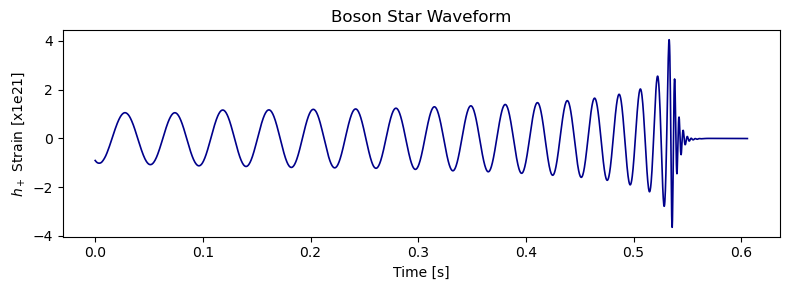

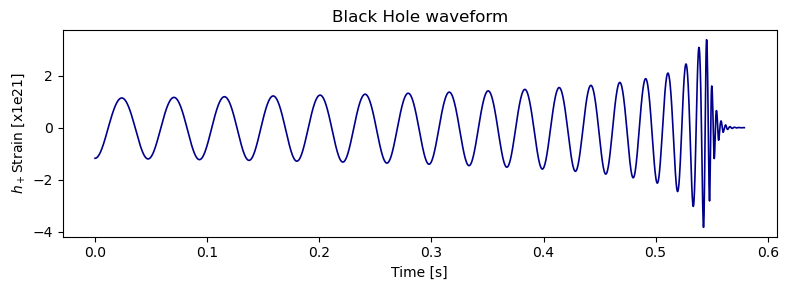

In [16]:
fig_bs, ax_bs = plt.subplots(1, 1, figsize=(8, 3))
#ax_bs.plot(nr_t, 1.0e21 * nr_hp, lw=1.2, label=r'$h_+$')
ax_bs.plot(nr_t_shift, -(1.0e21 * nr_hp), lw=1.2, color='darkblue')
#ax_bs.plot(bh_t, 1.0e21 * bh_hp, lw=1.2, label=r'NRSur7dq4 $h_+$')
#ax_bs.plot(nr_t_rel, 1.0e21 * nr_hc, lw=1.2, label=r'$h_\times$')
ax_bs.set_xlabel('Time [s]')
ax_bs.set_ylabel('$h_+$ Strain [x1e21]')
ax_bs.set_title('Boson Star Waveform')
#ax_bs.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig_bh, ax_bh = plt.subplots(1, 1, figsize=(8, 3))
ax_bh.plot(bh_t, 1.0e21 * bh_hp, lw=1.2, color='darkblue')
#ax_bh.plot(bh_t_rel, 1.0e21 * bh_hp_aligned, lw=1.2, label=r'NRSur7dq4 $h_+$')
#ax_bh.plot(bh_t_rel, 1.0e21 * bh_hc_aligned, lw=1.2, label=r'NRSur7dq4 $h_\times$')
ax_bh.set_xlabel('Time [s]')
ax_bh.set_ylabel('$h_+$Strain [x1e21]')
ax_bh.set_title('Black Hole waveform')
#ax_bh.legend(loc='upper left')
plt.tight_layout()
plt.show()